# Lab 3: Data Visualizations and Python Functions

Welcome to Lab 3! This week, you'll get to practice some DataFrame methods (especially `groupby`), create data visualizations, and learn how to define your very own functions in Python. Creating functions may be new to you, but don't worry, this assignment will guide you through that process! You should complete this entire lab so that all tests pass.

The topics on this lab are covered in [Functions](https://notes.dsc10.com/01-getting_started/functions-defining.html), [Grouping](https://notes.dsc10.com/02-data_sets/groupby.html), [Applying Functions](https://notes.dsc10.com/02-data_sets/apply.html) in the pandas notes and [Chapter 7](https://inferentialthinking.com/chapters/07/Visualization.html) in the CIT textbook.

**Please do not use `for`-loops for any questions in this lab.** If you don't know what a `for`-loop is, don't worry - we haven't covered them yet. But if you do know what they are and are wondering why it's not OK to use them, it is because loops in Python are slow, and looping over arrays and DataFrames should usually be avoided.

First, set up the tests and imports by running the cell below.


In [1]:
in_colab = "google.colab" in str(get_ipython())
if in_colab:
    !pip install otter-grader==6.1.6

from pathlib import Path
import numpy as np
np.set_printoptions(legacy='1.21')

# These lines set up graphing capabilities.
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)

import pandas as pd

path = 'labs/lab03/build/student'
if in_colab:
    import shutil
    import zipfile

    assets = ['data', 'tests']
    missing_assets = [asset for asset in assets if not Path(asset).exists()]
    if missing_assets:
        !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
        with zipfile.ZipFile('/content/course.zip') as course_zip:
            for asset in missing_assets:
                archive_prefix = f"cosmos-ml-cluster-2026-main/{path}/{asset}/"
                members = [name for name in course_zip.namelist() if name.startswith(archive_prefix)]
                if members:
                    course_zip.extractall('/content/course-assets', members)
                    source_path = Path('/content/course-assets') / archive_prefix
                    if source_path.exists():
                        shutil.copytree(source_path, asset, dirs_exist_ok=True)

import otter
grader = otter.Notebook()


## 1. Fortune 500 Companies 💯💯💯💯💯

Throughout this lab, we'll look at the 2022 revenue of the 500 highest-earning companies in the United States. The data was compiled for the 2023 edition of Fortune magazine's [Fortune 500 list](https://fortune.com/ranking/global500/2023/search/), which ranks the 500 largest corporations in the United States by their total revenue in the year 2022. See Fortune's [methodology page](https://fortune.com/franchise-list-page/fortune-500-methodology-2023/) for more details.

We've copied the data from the Fortune magazine page into a file called `raw_fortune_500.csv`.  Note that all dollar amounts are in billions of dollars.

In [2]:
raw_fortune_500 = pd.read_csv('data/raw_fortune_500.csv').set_index('Rank')
raw_fortune_500

,Name,Industry,Sector,Headquarters,Revenue,% Change,Profit,Asset,Market Value,Employees
Rank,,,,,,,,,,
1,Walmart,General Merchandisers,Retailing,"Bentonville, AR",$611.29,7%,$11.68,$243.20,$397.48,2100000
2,Amazon,Internet Services and Retailing,Retailing,"Seattle, WA",$513.98,9%,$2.72,$462.68,$1058.44,1541000
3,Exxon Mobil,Petroleum Refining,Energy,"Irving, TX",$413.68,45%,$55.74,$369.07,$446.42,62000
4,Apple,"Computers, Office Equipment",Technology,"Cupertino, CA",$394.33,8%,$99.80,$352.76,$2609.04,164000
5,UnitedHealth Group,Health Care: Insurance and Managed Care,Health Care,"Minnetonka, MN",$324.16,13%,$20.12,$245.70,$440.85,400000
...,...,...,...,...,...,...,...,...,...,...
496,KKR,Securities,Financials,"New York, NY",$7.27,-72%,$0.84,$277.08,$45.22,4150
497,Equinix,Real Estate,Financials,"Redwood City, CA",$7.26,9%,$0.70,$30.31,$66.87,12097
498,Sonoco Products,"Packaging, Containers",Materials,"Hartsville, SC",$7.25,(No previous year),$0.47,$7.05,$5.98,22000


We want to compute the average of the companies' revenues. Try running the cell below. 🚨 When you're done, make sure to comment it out.

In [3]:
# # After running this cell to see the error, please prevent it from running again
# # by placing a '#' in front of the line of code to 'comment it out'.
# raw_fortune_500.get('Revenue').mean()

You should see an error. Let's examine why this error occured by looking at the values in the `'Revenue'` column. 

**Question 1.1.** Use the `type` function to set `revenue_type` to the data type of the first item from the `'Revenue'` column. 

In [4]:
revenue_type = type(raw_fortune_500.get('Revenue').iloc[0]) # SOLUTION
revenue_type

str

In [5]:
revenue_type != np.ndarray

True

In [6]:
revenue_type != int

True

In [7]:
'str' in str(revenue_type)

True

**Question 1.2.** You should have found that the values in the `'Revenue'` column are stored as strings (text). It doesn't make sense to take the average of text values, so we need to convert them to numbers if we want to do this. Extract the first value in the `'Revenue'` column.  It's the 2022 revenue of Walmart, the highest-earning company in 2022, in *billions* of dollars. Call it `walmart_revenue_string`.

In [8]:
walmart_revenue_string = raw_fortune_500.get('Revenue').iloc[0] # SOLUTION
walmart_revenue_string

'$611.29'

In [9]:
walmart_revenue_string == '$611.29'

True

**Question 1.3.** Using code, convert `walmart_revenue_string` to a number of *dollars* as a float and store the result in the variable `walmart_revenue`.  
- The string method `strip` will be useful for removing the dollar sign; it removes a specified character from the start or end of a string.  For example, the value of `'100%'.strip('%')` is the string `'100'`.  
- You'll also need the function `float`, which converts a string that looks like a number to an actual number.  
- Last, remember that the answer should be in dollars, not billions. 

In [10]:
walmart_revenue = float(walmart_revenue_string.strip('$')) * 1000000000 # SOLUTION
walmart_revenue

611290000000.0

In [11]:
""" # BEGIN TEST CONFIG
failure_message: "It looks like your answer is still a string."
""" # END TEST CONFIG
type(walmart_revenue) != str 

True

In [12]:
""" # BEGIN TEST CONFIG
failure_message: "Don't forget the data is given in billions of dollars, and you want dollars."
""" # END TEST CONFIG
walmart_revenue != 611.29 

True

In [13]:
walmart_revenue == 611290000000

True

To compute the average revenue, we need to do this for every company.  But that looks like it would involve copying this code 500 times. No, thanks! 🙅

This is where functions come in.  Suppose instead of `walmart_revenue_string`, we had a variable called `some_revenue_string`, formatted in the same way as `walmart_revenue_string` is, with a dollar sign followed by an amount. Now that we've done it for `walmart_revenue_string`, we could use essentially the same code on `some_revenue_string` to extract the revenue as a number of dollars. You'd just need to change `walmart_revenue_string` in your code to `some_revenue_string`.

**Question 1.4.** Inside the function below, type the word `return` (which should turn green), then copy the expression you used to compute `walmart_revenue`, but replace the specific `walmart_revenue_string` with the generic `some_revenue_string`.

In [14]:
def convert_revenue_string_to_number(some_revenue_string):
    """Converts a revenue string like '$100' (in billions) to a number of dollars."""
    # After the word return, put your code to convert some_revenue_string to a number of dollars.
    # BEGIN SOLUTION
    return float(some_revenue_string.strip('$')) * 1000000000
    # END SOLUTION

In [15]:
convert_revenue_string_to_number('$100') == 100000000000.0

True

In [16]:
convert_revenue_string_to_number('$23') == 23000000000.0

True

In [17]:
convert_revenue_string_to_number('$29.68') == 29680000000.0

True

Here, we've defined a new function, giving a name to the expression that converts `'Revenue'` strings to numeric values. This function can convert any string with the right format representing billions of dollars (like `'$100'`) to a number in dollars. Later in this lab we'll see the payoff – we can call (use) that function on every revenue string in the dataset at once.

We can call our function just like we call the built-in functions we've seen. It takes one argument, a string, and it returns a number.

In [18]:
convert_revenue_string_to_number('$42')

42000000000.0

In [19]:
convert_revenue_string_to_number(walmart_revenue_string)

611290000000.0

In [20]:
# We can also compute Amazon's revenue in the same way:
convert_revenue_string_to_number(raw_fortune_500.get('Revenue').iloc[1])

513980000000.0

What have we gained?  Well, without the function, we'd have to copy that the code to strip the dollar sign, convert to afloat, and multiply by one billion **every time** we wanted to convert a revenue string.  Now we just call a function whose name says exactly what it's doing.

Soon, we'll see how to apply this function to every revenue string with a single expression. First, let's take a closer look at how to create our own functions.

## 2. Defining Functions ➗

Let's create a very simple function that converts a proportion to a percentage by multiplying it by 100.  For example, the value of `to_percentage(0.5)` should be the number 50.  (No percent sign.)

A function definition has a few parts.

##### `def`
It always starts with `def` (short for **def**ine):

```py
def
```

##### Name
Next comes the name of the function.  Let's call our function `to_percentage`.

```py
def to_percentage
```

##### Signature
Next comes something called the *signature* of the function.  This tells Python how many *arguments* your function should have, and what names you'll use to refer to those arguments in the function's code.  `to_percentage` should take one argument, and we'll call that argument `proportion` since it should be a proportion.

```py
def to_percentage(proportion)
```

We put a colon after the signature to tell Python it's over.

```py
def to_percentage(proportion):
```

##### Documentation
Functions can do complicated things, so **you should write an explanation of what your function does**.  For small functions, this is less important, but it's a good habit to learn from the start.  Conventionally, Python functions are documented by writing a triple-quoted string:

```py
def to_percentage(proportion):
    """Converts a proportion to a percentage."""
```
    
    
##### Body
Now we start writing code that runs when the function is called.  This is called the *body* of the function.  We can write anything we could write anywhere else.  First let's give a name to the number we multiply a proportion by to get a percentage.

```py
def to_percentage(proportion):
    """Converts a proportion to a percentage."""
    factor = 100
```

##### `return`
The special instruction `return` in a function's body tells Python to make the value of the function call equal to whatever comes right after `return`. The return statement also *ends the function* and once it's called *no lines in the body after it are run*. Since we want the value of `to_percentage(0.5)` to be the proportion 0.5 times the factor 100, we write:

```py
def to_percentage(proportion):
    """Converts a proportion to a percentage."""
    factor = 100
    return proportion * factor
```

**Question 2.1.** Define the function `to_percentage` in the cell below.  Call your function to convert the proportion `0.2` to a percentage.  Name that percentage `twenty_percent`.

In [21]:
def to_percentage(proportion):
    """ Converts a proportion to a percentage """
    # BEGIN SOLUTION
    factor = 100
    return proportion * factor
    # END SOLUTION

In [22]:
callable(to_percentage)

True

In [23]:
to_percentage(0.35) == 35.0

True

In [24]:
twenty_percent = to_percentage(0.2) # SOLUTION
twenty_percent

20.0

In [25]:
twenty_percent == 20.0

True

As with built-in functions (like `max` and `abs`), you can pass in variable names as arguments to functions you define yourself.

**Question 2.2.** Use `to_percentage` again to convert the proportion named `a_proportion` (defined below) to a percentage called `a_percentage`.

***Note:*** You don't need to define `to_percentage` again!  Just like other named things, functions stick around after you define them.

In [26]:
a_proportion = (2 ** 0.5) / 2
a_proportion

0.7071067811865476

In [27]:
a_percentage = to_percentage(a_proportion) # SOLUTION
a_percentage

70.71067811865476

In [28]:
bool(np.isclose(a_percentage, 70.71067811865476))

True

Here's an important fact about functions: the variable names assigned within a function's body are only accessible within that function's body. Once the function has returned, those names are gone. So even though you defined `factor = 100` inside `to_percentage` above and then called `to_percentage`, the variable name `factor` has no meaning outside the body of `to_percentage`.

To show you what we mean, run the following cell. **It intentionally causes an error**. 🚨 When you're done, comment it out.

In [29]:
# # You should see an error when you run this.  (If you don't, you might
# # have defined factor somewhere above.) Comment this code out
# # after running it to prevent the error in the future.

# factor

If we wanted to, we could define a new variable with the name `factor` outside of the definition of `to_percentage`, and it could have any value we want.

As we've seen with the built-in functions, functions can also take strings (or arrays, or DataFrames) as arguments, and they can return those things, too.

**Question 2.3.** Define a function called `disemvowel`.  It should take a single string as its argument. It should return a copy of that string, but with all the characters that are vowels removed. You can assume that `disemvowel` will only be called on lowercase strings, meaning that you only have to get rid of lowercase vowels. (In English, the vowels are the characters 'a', 'e', 'i', 'o', and 'u'. We won't count 'y'.)

***Hints:*** 
- To remove all the `'a'`s from a string, you can use `that_string.replace('a', '')`. 
- You can call `replace` multiple times on a single string, e.g. `'hey'.replace('e', 'o').replace('y', 'w')` is valid code.
- Use the same strategy we used when writing the function `convert_revenue_string_to_number`: start by writing code that does the desired operation on a particular example (like `walmart_revenue_string`). Once that's working, generalize your code to work for an arbitrary example, and then put it inside a function. Feel free to add additional cells as needed.

In [30]:
def disemvowel(a_string):
    # BEGIN SOLUTION
    new_string = a_string.replace('a', '').replace('e', '').replace('i', '').replace('o', '').replace('u', '')
    return new_string
    # END SOLUTION
    
# An example call to your function. Make sure to try out other examples too, 
# to make sure your function works as intended. Feel free to change the line below.
disemvowel('can you read this without vowels?')

'cn y rd ths wtht vwls?'

In [31]:
disemvowel('datascience rules!') != 'datascience rules!'

True

In [32]:
disemvowel('datascience rules!') == 'dtscnc rls!'

True

In [33]:
disemvowel('uc san diego') == 'c sn dg'

True

##### Calls on calls on calls
Just as you write a series of lines to build up a complex computation, it's useful to define a series of small functions that build on each other.  Since you can write any code inside a function's body, you can call other functions you've written.

If a function is a like a recipe, defining a function in terms of other functions is like having a recipe for cake 🍰 telling you to follow another recipe to make the frosting, and another to make the filling.  This makes the cake recipe shorter and clearer, and it avoids having a bunch of duplicated frosting recipes.  It's a foundation of productive programming.

For example, suppose you want to count the number of characters *that aren't vowels* in a piece of text.  One way to do that is this to remove all the vowels and count the size of the remaining string.

**Question 2.4.** Write a function called `num_non_vowels`.  It should take a string as its argument and return a number.  The number should be the number of characters in the argument string that aren't vowels. Again, you can assume that `num_non_vowels` will only be called on lowercase strings.

***Hint:*** The function `len` takes a string as its argument and returns the number of characters in it.

In [34]:
def num_non_vowels(a_string):
    """The number of characters in a string, not counting any vowels."""
    # BEGIN SOLUTION
    without_vowels = disemvowel(a_string)
    return len(without_vowels)
    # END SOLUTION

In [35]:
num_non_vowels('go tritons!') == 8

True

In [36]:
num_non_vowels('uc san diego') == 7

True

Functions can also encapsulate code that *does things* rather than just computing values.  For example, if you call `print` inside a function, and then call that function, something will be printed.

Let's make use of a dataset of the top 500 all-time most streamed songs on Spotify, which we have loaded into the variable `spotify_streams` below. Note that the songs are sorted alphabetically by title.

In [37]:
spotify_streams = pd.read_csv('data/spotify_streams.csv').set_index('Song')
spotify_streams

,Artist,Streams (Billions)
Song,,
1-800-273-8255,Logic,1.352988
2002,Anne-Marie,1.573897
24K Magic,Bruno Mars,1.500159
505,Arctic Monkeys,1.808410
7 Years,Lukas Graham,2.004016
...,...,...
telepatía,Kali Uchis,1.229562
"thank u, next",Ariana Grande,1.922892
traitor,Olivia Rodrigo,1.667873


Suppose you'd like to display the name of the song with the 5th most streams, printed in a human-readable way. You might do this:

In [38]:
rank = 5
fifth_most_streamed_song = spotify_streams.sort_values(by='Streams (Billions)', ascending=False).index[rank-1]

print('The song ranked number', rank, 'for most all-time Spotify streams is', fifth_most_streamed_song)

The song ranked number 5 for most all-time Spotify streams is Sunflower


After writing this, you realize you also wanted to print out the 2nd and 3rd-most streamed songs.  Instead of copying your code, you decide to put it in a function.  Since the rank varies, you make that an argument to your function.

**Question 2.5.** Write a function called `print_kth_most_streamed_song`.  It should take a single argument, the rank of the song's number of streams (like 2, 3, or 5 in the above examples).  It should use the `spotify_streams` DataFrame to determine the song at rank `k` and print out a message like the one above.  The function should not have a `return` statement, because we want the function to print, not return.

In [39]:
def print_kth_most_streamed_song(k):
    # BEGIN SOLUTION
    kth_most_streamed_song = spotify_streams.sort_values(by='Streams (Billions)', ascending=False).index[k-1]
    print('The song ranked number', k, 'for most all-time Spotify streams is', kth_most_streamed_song)
    # END SOLUTION

In [40]:
# Example calls to your function:
print_kth_most_streamed_song(2)
print_kth_most_streamed_song(3)

The song ranked number 2 for most all-time Spotify streams is Shape of You
The song ranked number 3 for most all-time Spotify streams is Someone You Loved


## 3. Applying Functions 🩹

Defining a function is a lot like giving a name to a value with `=`.  In fact, a function is a value just like the number 1 or the string `'hey'`!

For example, we can make a new name for the built-in function `max` if we want:

In [41]:
the_largest_of = max
the_largest_of(10, 11)

11

The old name for `max` is still around:

In [42]:
max(10, 11)

11

Since functions are just values, it's possible to pass them as arguments to other functions.  Here's a simple but not-so-practical example: we can make an array of functions.

In [43]:
np.array([max, np.average, type])

array([<built-in function max>, <function average at 0x10935a970>,
       <class 'type'>], dtype=object)

**Question 3.1.** Make an array containing any 3 other functions you've seen.  Call it `some_functions`. Do not import any packages.

In [44]:
some_functions = np.array([num_non_vowels, print_kth_most_streamed_song, disemvowel]) # SOLUTION
some_functions

array([<function num_non_vowels at 0x1153a6090>,
       <function print_kth_most_streamed_song at 0x1153a5380>,
       <function disemvowel at 0x1090a2cf0>], dtype=object)

In [45]:
len(some_functions) == 3

True

In [46]:
callable(some_functions[0])

True

In [47]:
callable(some_functions[1])

True

In [48]:
callable(some_functions[2])

True

Working with functions as values can lead to some funny-looking code.  For example, see if you can figure out how this line of code works:

In [49]:
np.array([max, np.average, type])[0](4, -2, 7)

7

Here's a simpler example that's actually useful: the Series method `apply`.
`apply` calls a function many times, once on *each* element of a Series, which typically comes from a column of a DataFrame. It produces a Series of the results, which we may want to then add to a DataFrame.

Here's an example. Remember that the `'Revenue'` column of the `fortune_500` DataFrame contained strings:

In [50]:
raw_fortune_500.get('Revenue')

Rank
1      $611.29
2      $513.98
3      $413.68
4      $394.33
5      $324.16
        ...   
496      $7.27
497      $7.26
498      $7.25
499      $7.24
500      $7.24
Name: Revenue, Length: 500, dtype: str

We wrote a function, `convert_revenue_string_to_number`, that converts one of these strings to a number.
Here we use `apply` to convert every company's revenue to a number, using the function you defined:

Here's an illustration of what that did:

<img src="data/apply-review.jpg" width=700/>

Note that we didn't write something like `convert_revenue_string_to_number()` or `convert_revenue_string_to_number('Revenue')`.  The job of `apply` is to call the function we give it, so instead of calling `convert_revenue_string_to_number` ourselves, we just write its name as an argument to `apply`.

**Question 3.2.** Using `apply`, make a DataFrame that's a copy of `raw_fortune_500`, but use `.assign` to add a new column called `'Revenue_Dollars'`.  It should be the result of applying `convert_revenue_string_to_number` to the `'Revenue'` column, as we did above.  Call the new DataFrame `fortune_500`. Since the revenue of these companies in dollars is so large, the `'Revenue_Dollars'` column will display in scientific notation.

In [51]:
fortune_500 = raw_fortune_500.assign(Revenue_Dollars=raw_fortune_500.get('Revenue').apply(convert_revenue_string_to_number)) # SOLUTION
fortune_500

,Name,Industry,Sector,Headquarters,Revenue,% Change,Profit,Asset,Market Value,Employees,Revenue_Dollars
Rank,,,,,,,,,,,
1,Walmart,General Merchandisers,Retailing,"Bentonville, AR",$611.29,7%,$11.68,$243.20,$397.48,2100000,6.112900e+11
2,Amazon,Internet Services and Retailing,Retailing,"Seattle, WA",$513.98,9%,$2.72,$462.68,$1058.44,1541000,5.139800e+11
3,Exxon Mobil,Petroleum Refining,Energy,"Irving, TX",$413.68,45%,$55.74,$369.07,$446.42,62000,4.136800e+11
4,Apple,"Computers, Office Equipment",Technology,"Cupertino, CA",$394.33,8%,$99.80,$352.76,$2609.04,164000,3.943300e+11
5,UnitedHealth Group,Health Care: Insurance and Managed Care,Health Care,"Minnetonka, MN",$324.16,13%,$20.12,$245.70,$440.85,400000,3.241600e+11
...,...,...,...,...,...,...,...,...,...,...,...
496,KKR,Securities,Financials,"New York, NY",$7.27,-72%,$0.84,$277.08,$45.22,4150,7.270000e+09
497,Equinix,Real Estate,Financials,"Redwood City, CA",$7.26,9%,$0.70,$30.31,$66.87,12097,7.260000e+09
498,Sonoco Products,"Packaging, Containers",Materials,"Hartsville, SC",$7.25,(No previous year),$0.47,$7.05,$5.98,22000,7.250000e+09


In [52]:
'Revenue_Dollars' in fortune_500.columns

True

In [53]:
fortune_500.shape == (500, 11)

True

In [54]:
t = fortune_500.sort_values('Revenue_Dollars', ascending=False)
bool(t.get('Revenue_Dollars').values[0] == 611290000000.0)

True

Now that we have the revenues as floats instead of strings, we can perform arithmetic operations (and, as a result, compute numerical summaries) on the revenue values.

**Question 3.3.** Compute the average revenue of the companies in the dataset, in dollars.

In [55]:
average_revenue = fortune_500.get('Revenue_Dollars').mean() # SOLUTION
average_revenue

36288520000.0

In [56]:
bool(np.isclose(average_revenue, 36288520000.0))

True

**Question 3.4.** Although Walmart has the highest revenue in `fortune_500`, we can see that some other companies such as Apple have higher profit. This is because profit takes into account expenses such as operating costs and debts, whereas revenue does not take expenses into account. Compute the proportion of each company's revenue that ended up as profit. (Your answer should be a Series.)

In [57]:
profit_proportion = fortune_500.get('Profit').apply(convert_revenue_string_to_number) / fortune_500.get('Revenue_Dollars') #SOLUTION
profit_proportion

Rank
1      0.019107
2      0.005292
3      0.134742
4      0.253088
5      0.062068
         ...   
496    0.115543
497    0.096419
498    0.064828
499    0.044199
500    0.091160
Length: 500, dtype: float64

In [58]:
isinstance(profit_proportion, pd.Series)

True

In [59]:
len(profit_proportion) == 500

True

In [60]:
bool(np.isclose(profit_proportion.loc[1], 0.01910713))

True

**Question 3.5.** Notice that each company in the dataset belongs to a specific industry sector, as indicated in the `'Sector'` column. Construct an appropriate visualization to display the **median revenue by sector**, sorted in descending order so that the sector with the highest median revenue appears first. 

***Hint:*** You'll first need to calculate the median revenue for each sector. `.groupby` will be helpful!

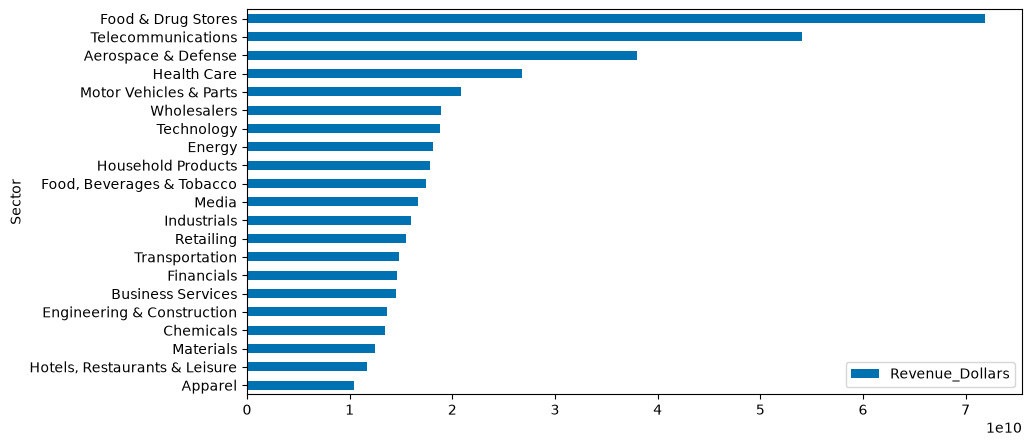

In [61]:
# Create your plot here.
# BEGIN SOLUTION
fortune_500.get(["Revenue_Dollars", "Sector"]).groupby('Sector').median().sort_values(by='Revenue_Dollars').plot(kind="barh", y="Revenue_Dollars");
# END SOLUTION

## 4. Last Year's Revenue ⏮

Check out the `'% Change'` column in `fortune_500`.  It shows the percentage increase in the company's revenue from the previous year.  For companies that were not part of the Fortune 500 in the previous year, it instead says `'(No previous year)'`.  The values in this column are *strings*, not numbers, so they are not usable without a bit of extra work.

Given your current revenue and the percentage increase from the previous year, you can compute your previous year's revenue. This year's revenue and last year's revenue are related by the formula:

$$\text{this year's revenue} = \text{last year's revenue} \cdot \left(1+\dfrac{\text{percent increase}}{100}\right)$$

For example, if your company made \$600,000 last year and your revenue increased by 50\%, then 

$$\begin{align}
\text{this year's revenue} &= \text{600000} \cdot \left(1+\dfrac{\text{50}}{100}\right)\\
&= \text{600000} \cdot (1.5) \\
&= 900000
\end{align}$$

Since we know how this year's revenue and last year's revenue are mathematically related, we can solve this equation for last year's revenue to give a formula for the previous year's revenue if we know the current year's revenue and the percent increase from the previous year to the current year. Doing some algebra, we find:

$$\text{last year's revenue} = \dfrac{\text{this year's revenue}}{\left(1+\dfrac{\text{percent increase}}{100}\right)}$$

**Question 4.1.** Create a new DataFrame called `with_previous_fortune_500`.  It should be a copy of `fortune_500`, but with the `'(No previous year)'` companies filtered out, and with an extra column called `'Previous_Revenue'`.  That column should have each company's revenue in 2021 (because remember, the values in the `'Revenue'` column contain 2022 revenues).

***Hints:***
- This question takes several steps, but each one involves something you've already learned how to do.  Take it one step at a time, using as many lines as you need.  You can print out your results after each step to make sure you're on the right track.
- You'll need to define a function to convert percentage strings, like `'-15%'`, to numbers.  You can do that just above your other code.
- If you see an error saying `unsupported operand type(s) for +: 'int' and 'Series'`, try switching the order of your operation. Instead of writing something like `1 + series`, write `series + 1`.

***Note:*** Don't use the `~` symbol anywhere inside your code, or the  autograder may not be able to grade your work.

In [62]:
# You can write code to perform intermediate steps here!
# BEGIN SOLUTION NO PROMPT
def convert_percentage_string_to_number(s):
    return int(s.strip('%')) * .01

filtered_fortune_500 = fortune_500[fortune_500.get('% Change') != '(No previous year)']
revenue = filtered_fortune_500.get('Revenue_Dollars')
pct_change = filtered_fortune_500.get('% Change').apply(convert_percentage_string_to_number)
prev_revenue = revenue / (pct_change + 1)
# END SOLUTION
with_previous_fortune_500 = filtered_fortune_500.assign(Previous_Revenue=prev_revenue) # SOLUTION
with_previous_fortune_500

,Name,Industry,Sector,Headquarters,Revenue,% Change,Profit,Asset,Market Value,Employees,Revenue_Dollars,Previous_Revenue
Rank,,,,,,,,,,,,
1,Walmart,General Merchandisers,Retailing,"Bentonville, AR",$611.29,7%,$11.68,$243.20,$397.48,2100000,6.112900e+11,5.712991e+11
2,Amazon,Internet Services and Retailing,Retailing,"Seattle, WA",$513.98,9%,$2.72,$462.68,$1058.44,1541000,5.139800e+11,4.715413e+11
3,Exxon Mobil,Petroleum Refining,Energy,"Irving, TX",$413.68,45%,$55.74,$369.07,$446.42,62000,4.136800e+11,2.852966e+11
4,Apple,"Computers, Office Equipment",Technology,"Cupertino, CA",$394.33,8%,$99.80,$352.76,$2609.04,164000,3.943300e+11,3.651204e+11
5,UnitedHealth Group,Health Care: Insurance and Managed Care,Health Care,"Minnetonka, MN",$324.16,13%,$20.12,$245.70,$440.85,400000,3.241600e+11,2.868673e+11
...,...,...,...,...,...,...,...,...,...,...,...,...
486,Genworth Financial,"Insurance: Life, Health (Stock)",Financials,"Richmond, VA",$7.51,-5%,$0.61,$86.44,$2.48,2500,7.510000e+09,7.905263e+09
489,Landstar System,"Trucking, Truck Leasing",Transportation,"Jacksonville, FL",$7.44,14%,$0.43,$1.93,$6.46,1449,7.440000e+09,6.526316e+09
496,KKR,Securities,Financials,"New York, NY",$7.27,-72%,$0.84,$277.08,$45.22,4150,7.270000e+09,2.596429e+10


In [63]:
'(No previous year)' not in with_previous_fortune_500.get('% Change')

True

In [64]:
with_previous_fortune_500.shape[0] == 471

True

In [65]:
t = with_previous_fortune_500.sort_values(by='Previous_Revenue', ascending=False)
value = t.get('Previous_Revenue').values[0]
bool(np.isclose(value, 571299065420.5607))

True

**Question 4.2.** What was the average revenue of these companies in 2021?

In [66]:
average_revenue_2021 = with_previous_fortune_500.get('Previous_Revenue').mean() # SOLUTION
average_revenue_2021

33639790366.980835

In [67]:
bool(np.isclose(average_revenue_2021, 33639790366.98084))

True

Now, let's compare the performance of last year's revenue (2021) with this year's revenue (2022) for all Fortune 500 companies. We'll do this by creating a scatter plot that visualizes the relationship between these two variables.

**Question 4.3.** Plot a scatter plot with last year's revenue on the $x$-axis and this year's revenue on the $y$-axis.

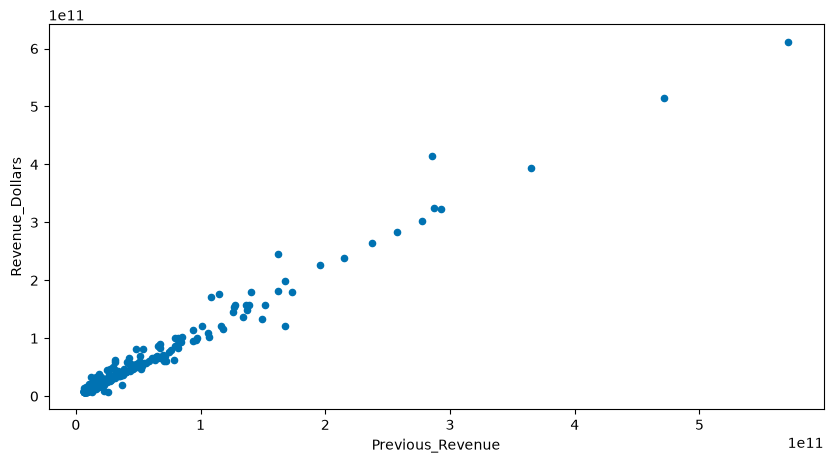

In [68]:
# Create your scatter plot here.
# BEGIN SOLUTION
with_previous_fortune_500.plot(kind='scatter', x='Previous_Revenue', y='Revenue_Dollars'); 
# END SOLUTION

The data follows a clear linear trend, meaning the `Previous_Revenue` column is a strong predictor of the current year's revenue. That makes sense!

## 5. Distribution of Revenue 💰
Earlier, we computed the average revenue among the companies in our 500-company dataset.  The average doesn't tell us everything about the amounts companies earn, though.  Maybe just a few companies make the bulk of the money, even among these 500.

We can use a *density histogram* to display more information about a set of numbers.  [Here's an example](https://dsc10.com/resources/lectures/lec07/lec07.html#Plotting-a-density-histogram) of the code that we use to create histograms. 

**Question 5.1.** Make a density histogram of the revenue of the companies in `fortune_500`. Use bins starting from 0 with a width of `0.5*10**11`.

***Hint:*** To determine the scale of your x-axis, look at the largest revenue in the dataset and make sure that it is included in the rightmost bin.

<Axes: ylabel='Frequency'>

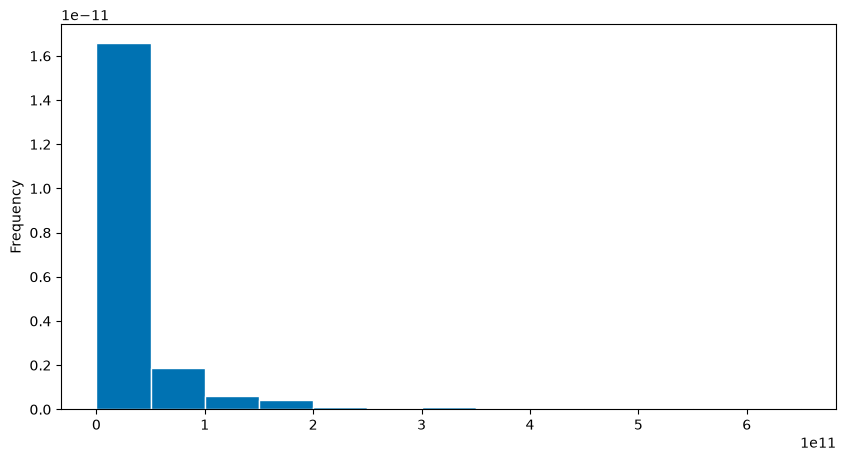

In [69]:
# Create your histogram here.
# BEGIN SOLUTION
fortune_500.get('Revenue_Dollars').plot(kind='hist', density=True, ec='w', bins=np.arange(0, 7*10**11, 0.5*10**11))
# END SOLUTION

**Question 5.2.** Looking at the histogram, about how many companies made more than \$100 billion in revenue? Make a good guess. (Answer the question by filling in your answer manually.  You'll have to do a bit of arithmetic; feel free to use Python as a calculator.)

In [70]:
num_companies_more_than_100_billion = 38 # SOLUTION

In [71]:
""" # BEGIN TEST CONFIG
failure_message: "this is a number of companies, it had better be an integer!"
""" # END TEST CONFIG
import numbers
isinstance(num_companies_more_than_100_billion, numbers.Integral) 

True

**Question 5.3.** Answer the same question with code. That is, find the number of companies with a revenue of over \$100 billion using code, and assign the result to the name `num_companies_more_than_100_billion_code`.

In [72]:
num_companies_more_than_100_billion_code = fortune_500[fortune_500.get('Revenue_Dollars') > 10 ** 11].shape[0] # SOLUTION
num_companies_more_than_100_billion_code

38

In [73]:
bool(num_companies_more_than_100_billion_code == 38)

True

Run the next cell if you want to see how far off you were.

In [74]:
percent_diff = abs(num_companies_more_than_100_billion - num_companies_more_than_100_billion_code) / num_companies_more_than_100_billion_code
print(f'Your guess was only {percent_diff * 100}% off!')

Your guess was only 0.0% off!


# Finish Line

Congratulations! You are done with Lab 3.

In [75]:
# For your convenience, you can run this cell to run all the tests at once!
grader.check_all()